# QUBO Formulation Complexity Comparison

Compares the **variable count** and **quadratic interaction count** of four Steiner Tree QUBO formulations across two graph density regimes.

### Formulations
| Label | Description |
|---|---|
| **Daghan v6** | Flow-based (arc flow variables + capacity + opposite-direction + arc-use constraints) |
| **Alex (ordering)** | Ordering-based (pairwise ordering variables enforce acyclicity without depth encoding) |
| **Hybrid** | Directed arc variables + binary depth encoding + non-terminal usage bits |
| **Li et al.** | Path-based formulation from the reference paper |

### Graph families
| Family | Generator | Expected edge count |
|---|---|---|
| **Dense** | Erdős–Rényi G(n, p = 0.7) | ≈ 0.35 · n² |
| **Sparse** | k-NN geometric graph (y = 4 neighbors per node) | ≈ 2·n |

Each data point is the **mean over 5 random instances** with k = ⌈n/3⌉ terminals (at least 2).

In [47]:
import sys
import os
import math

import numpy as np
import matplotlib.pyplot as plt

# The formulation modules use `from SteinerTreeProblemQUBO.X import Y`,
# so the project root (parent of this notebook's directory) must be on sys.path.
sys.path.insert(0, os.path.abspath('..'))

from SteinerTreeProblemQUBO.random_problem_generator import (
    generate_erdos_renyi_steiner_tree,
    generate_geometric_steiner_tree,
)
from SteinerTreeProblemQUBO.MyFormulization.steiner_to_bqm_daghan import steiner_to_bqm_daghan
from SteinerTreeProblemQUBO.MyFormulization.steiner_to_bqm_alex import steiner_to_bqm_ordering
from SteinerTreeProblemQUBO.MyFormulization.steiner_to_bqm_hybrid import steiner_to_bqm_hybrid
from SteinerTreeProblemQUBO.Li_et_al.steiner_to_bqm import steiner_to_bqm_Li_et_al

print('Imports OK')

Imports OK


In [ ]:
# ---------------------------------------------------------------------------
# Experiment configuration
# ---------------------------------------------------------------------------

NODE_SIZES        = range(4, 100, 4)
NUM_INSTANCES     = 2      # random seeds averaged per (n, graph-type) combination
CONSTRAINT_WEIGHT = 1.0   # same penalty weight for all formulations that need one
SPARSE_DEGREE     = 4     # each node connects to this many nearest neighbors => |E| ≈ y·n/2


def terminal_count(n: int) -> int:
    """Number of terminals: ceil(n/3), at least 2."""
    return max(2, math.ceil(n / 3))


# Each value is a callable (SteinerTree) -> BinaryQuadraticModel.
FORMULATIONS = {
    "Daghan v8":       lambda p: steiner_to_bqm_daghan(p, CONSTRAINT_WEIGHT, version=8),
    "Alex (ordering)": lambda p: steiner_to_bqm_ordering(p),
    "Hybrid":          lambda p: steiner_to_bqm_hybrid(p, CONSTRAINT_WEIGHT),
}


# Dense: Erdos-Renyi G(n, p=0.7)  =>  expected |E| ~ 0.35 n^2
def dense_generator(n: int, k: int, seed: int):
    return generate_erdos_renyi_steiner_tree(
        node_count=n, terminal_count=k, edge_probability=0.7, seed=seed
    )


# Sparse: k-NN geometric graph with SPARSE_DEGREE nearest neighbors per node.
# Expected |E| ≈ SPARSE_DEGREE * n / 2  (each undirected edge is shared by two nodes).
def sparse_generator(n: int, k: int, seed: int):
    return generate_geometric_steiner_tree(
        node_count=n,
        terminal_count=k,
        connectivity='knn',
        k=SPARSE_DEGREE,
        seed=seed,
    )


print(f'Node sizes     : {NODE_SIZES}')
print(f'Terminals      : {[terminal_count(n) for n in NODE_SIZES]}')
print(f'Instances      : {NUM_INSTANCES} per (n, graph-type)')
print(f'Sparse degree  : {SPARSE_DEGREE} neighbors  =>  expected |E| ≈ {SPARSE_DEGREE}·n/2')

Node sizes     : range(4, 160, 4)
Terminals      : [2, 3, 4, 6, 7, 8, 10, 11, 12, 14, 15, 16, 18, 19, 20, 22, 23, 24, 26, 27, 28, 30, 31, 32, 34, 35, 36, 38, 39, 40, 42, 43, 44, 46, 47, 48, 50, 51, 52]
Instances      : 2 per (n, graph-type)
Sparse degree  : 4 neighbors  =>  expected |E| ≈ 4·n/2


In [49]:
# ---------------------------------------------------------------------------
# Sweep helper
# ---------------------------------------------------------------------------

def run_sweep(generator, node_sizes, num_instances, formulations, label=''):
    """
    Build BQMs for every (n, seed, formulation) triple and record the number
    of variables and quadratic interactions.

    Returns
    -------
    dict[str, dict]  with shape  {name: {"vars": [...], "ints": [...]}}
    where each inner list has one averaged entry per node size.
    """
    results = {name: {"vars": [], "ints": []} for name in formulations}

    for n in node_sizes:
        k = terminal_count(n)
        per_seed_vars = {name: [] for name in formulations}
        per_seed_ints = {name: [] for name in formulations}

        edge_counts = []
        for seed in range(num_instances):
            problem = generator(n, k, seed)
            edge_counts.append(len(problem.edges))

            for name, build_fn in formulations.items():
                bqm = build_fn(problem)
                per_seed_vars[name].append(len(bqm.variables))
                per_seed_ints[name].append(len(bqm.quadratic))

        for name in formulations:
            results[name]["vars"].append(float(np.mean(per_seed_vars[name])))
            results[name]["ints"].append(float(np.mean(per_seed_ints[name])))

        avg_edges = np.mean(edge_counts)
        row_parts = [f'n={n:2d}, k={k}, |E|≈{avg_edges:.1f}']
        for name in formulations:
            v = results[name]["vars"][-1]
            q = results[name]["ints"][-1]
            row_parts.append(f'{name}: {v:.0f}v / {q:.0f}q')
        print('  |  '.join(row_parts))

    return results

## Dense graphs — Erdős–Rényi G(n, p = 0.7)

Expected number of edges: $\approx 0.7 \cdot \dfrac{n(n-1)}{2} \sim n^2$

In [33]:
print('Running dense sweep ...\n')
dense_results = run_sweep(dense_generator, NODE_SIZES, NUM_INSTANCES, FORMULATIONS, label='dense')
print('\nDone.')

Running dense sweep ...

n= 4, k=2, |E|≈4.0  |  Alex (ordering): 9v / 17q  |  Hybrid: 34v / 163q
n= 8, k=3, |E|≈17.0  |  Alex (ordering): 51v / 256q  |  Hybrid: 179v / 1469q
n=12, k=4, |E|≈41.0  |  Alex (ordering): 131v / 1187q  |  Hybrid: 512v / 5861q
n=16, k=6, |E|≈76.0  |  Alex (ordering): 247v / 2897q  |  Hybrid: 926v / 11067q
n=20, k=7, |E|≈131.0  |  Alex (ordering): 417v / 6804q  |  Hybrid: 1835v / 27703q
n=24, k=8, |E|≈189.0  |  Alex (ordering): 613v / 11987q  |  Hybrid: 2656v / 40914q
n=28, k=10, |E|≈264.0  |  Alex (ordering): 863v / 20240q  |  Hybrid: 3742v / 58819q
n=32, k=11, |E|≈340.0  |  Alex (ordering): 1123v / 30482q  |  Hybrid: 4787v / 76381q
n=36, k=12, |E|≈441.0  |  Alex (ordering): 1447v / 44494q  |  Hybrid: 7056v / 133283q
n=40, k=14, |E|≈550.0  |  Alex (ordering): 1814v / 61373q  |  Hybrid: 8850v / 169185q
n=44, k=15, |E|≈672.0  |  Alex (ordering): 2216v / 84724q  |  Hybrid: 10797v / 209007q
n=48, k=16, |E|≈787.0  |  Alex (ordering): 2618v / 108012q  |  Hybrid: 126

## Sparse graphs — k-NN geometric graph (y = 4 neighbors per node)

Each node is connected to its `SPARSE_DEGREE = 4` nearest neighbors in a random 2-D point set.
Expected number of edges: $\approx \dfrac{y \cdot n}{2} = 2n \sim n$.

In [34]:
print('Running sparse sweep ...\n')
sparse_results = run_sweep(sparse_generator, NODE_SIZES, NUM_INSTANCES, FORMULATIONS, label='sparse')
print('\nDone.')

Running sparse sweep ...

n= 4, k=2, |E|≈6.0  |  Alex (ordering): 12v / 29q  |  Hybrid: 46v / 245q
n= 8, k=3, |E|≈20.0  |  Alex (ordering): 54v / 272q  |  Hybrid: 194v / 1627q
n=12, k=4, |E|≈28.0  |  Alex (ordering): 106v / 770q  |  Hybrid: 362v / 3897q
n=16, k=6, |E|≈37.0  |  Alex (ordering): 175v / 1775q  |  Hybrid: 494v / 5324q
n=20, k=7, |E|≈47.0  |  Alex (ordering): 260v / 3398q  |  Hybrid: 736v / 9758q
n=24, k=8, |E|≈59.0  |  Alex (ordering): 364v / 5979q  |  Hybrid: 913v / 12191q
n=28, k=10, |E|≈72.0  |  Alex (ordering): 490v / 9643q  |  Hybrid: 1131v / 15220q
n=32, k=11, |E|≈83.0  |  Alex (ordering): 624v / 14500q  |  Hybrid: 1294v / 17426q
n=36, k=12, |E|≈93.0  |  Alex (ordering): 776v / 20884q  |  Hybrid: 1688v / 26992q
n=40, k=14, |E|≈98.0  |  Alex (ordering): 932v / 28635q  |  Hybrid: 1794v / 28467q
n=44, k=15, |E|≈109.0  |  Alex (ordering): 1117v / 38369q  |  Hybrid: 2005v / 31856q
n=48, k=16, |E|≈118.0  |  Alex (ordering): 1311v / 50082q  |  Hybrid: 2160v / 34273q
n=52, k

## Plots

In [54]:
# ---------------------------------------------------------------------------
# Visual style
# ---------------------------------------------------------------------------

STYLE = {
    #"Daghan v8":       {"color": "#1f77b4", "marker": "o",  "ls": "-"},
    "Alex (ordering)": {"color": "#ff7f0e", "marker": "s",  "ls": "--"},
    "Hybrid":          {"color": "#2ca02c", "marker": "^",  "ls": "-."},
}


def plot_complexity(results, node_sizes, graph_label):
    """
    Two side-by-side panels (log-scale y-axis):
      left  — number of binary variables vs n
      right — number of quadratic interactions vs n
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    metrics = [
        ("vars", "Number of binary variables"),
        ("ints", "Number of quadratic interactions"),
    ]

    for ax, (key, ylabel) in zip(axes, metrics):
        for name in FORMULATIONS:
            s = STYLE[name]
            ax.plot(
                node_sizes,
                results[name][key],
                label=name,
                color=s["color"],
                marker=s["marker"],
                linestyle=s["ls"],
                linewidth=2,
                markersize=7,
            )
        ax.set_yscale("log")
        ax.set_xlabel("Number of nodes (n)", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(ylabel, fontsize=12)
        ax.set_xticks(node_sizes[::4])
        ax.legend(fontsize=10)
        ax.grid(True, which="both", alpha=0.3)

    fig.suptitle(
        f"QUBO Formulation Complexity — {graph_label}\n"
        f"(mean over {NUM_INSTANCES} instances, k = ⌈n/3⌉ terminals)",
        fontsize=13,
        fontweight="bold",
    )
    fig.tight_layout()
    plt.show()
    return fig

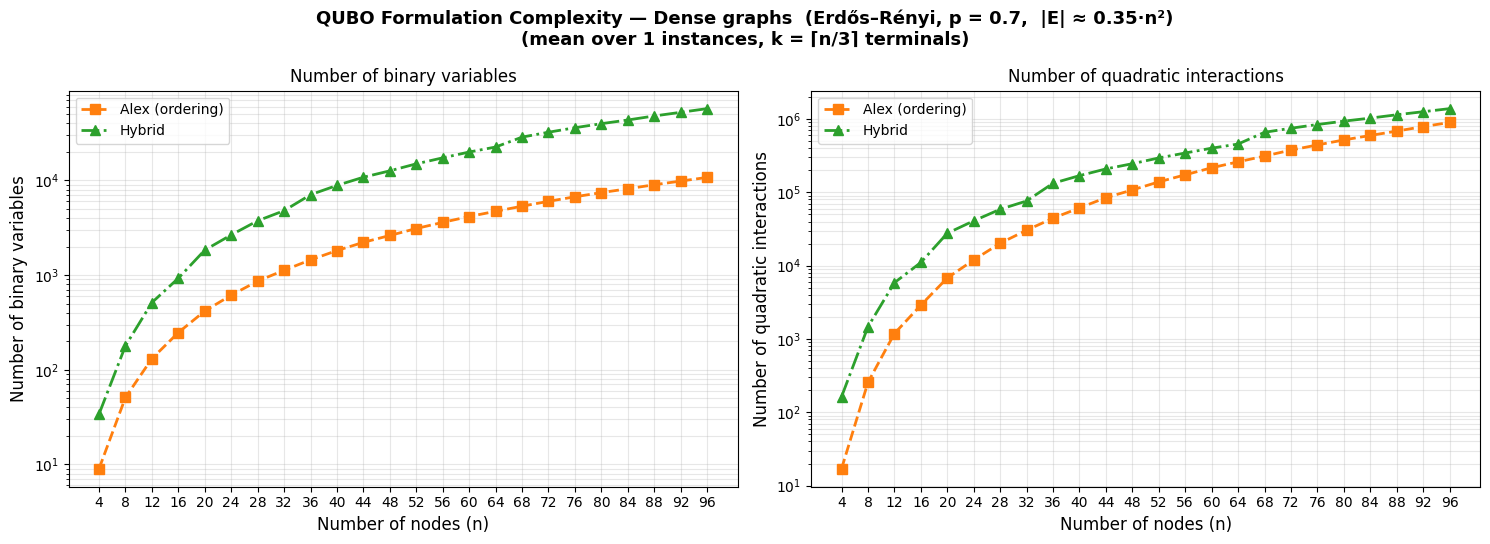

In [36]:
fig_dense = plot_complexity(
    dense_results,
    NODE_SIZES,
    graph_label="Dense graphs  (Erdős–Rényi, p = 0.7,  |E| ≈ 0.35·n²)",
)

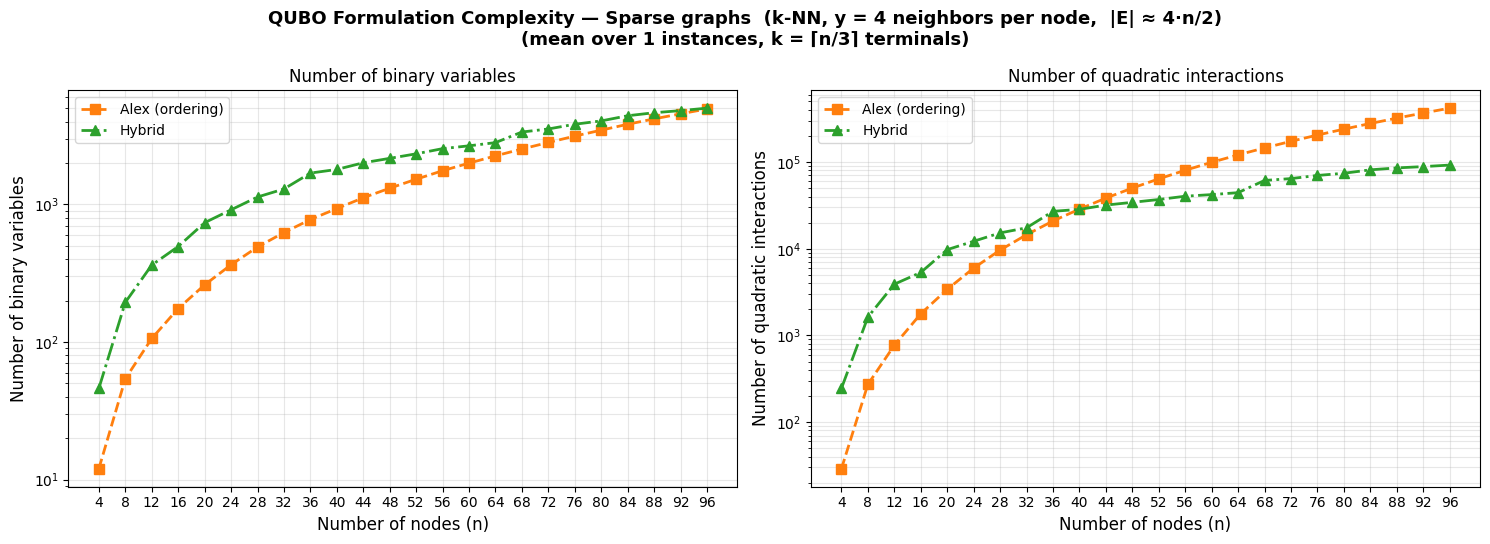

In [37]:
fig_sparse = plot_complexity(
    sparse_results,
    NODE_SIZES,
    graph_label=f"Sparse graphs  (k-NN, y = {SPARSE_DEGREE} neighbors per node,  |E| ≈ {SPARSE_DEGREE}·n/2)",
)

## Summary table

In [38]:
# Print a markdown-style table of the raw numbers at the largest tested size.
n_max = NODE_SIZES[-1]
idx   = len(NODE_SIZES) - 1

header = f"{'Formulation':<20} | {'Dense vars':>12} | {'Dense ints':>12} | {'Sparse vars':>12} | {'Sparse ints':>12}"
sep    = '-' * len(header)
print(f"Complexity at n = {n_max} (k = {terminal_count(n_max)})")
print(sep)
print(header)
print(sep)
for name in FORMULATIONS:
    dv = dense_results[name]["vars"][idx]
    di = dense_results[name]["ints"][idx]
    sv = sparse_results[name]["vars"][idx]
    si = sparse_results[name]["ints"][idx]
    print(f"{name:<20} | {dv:>12.1f} | {di:>12.1f} | {sv:>12.1f} | {si:>12.1f}")
print(sep)

Complexity at n = 96 (k = 32)
--------------------------------------------------------------------------------
Formulation          |   Dense vars |   Dense ints |  Sparse vars |  Sparse ints
--------------------------------------------------------------------------------
Alex (ordering)      |      10745.0 |     898891.0 |       4939.0 |     418350.0
Hybrid               |      57256.0 |    1388729.0 |       5002.0 |      92226.0
--------------------------------------------------------------------------------


# RUN 2

In [42]:
print('Running dense sweep ...\n')
dense_results2 = run_sweep(dense_generator, NODE_SIZES, NUM_INSTANCES, FORMULATIONS, label='dense')
print('\nDone.')

Running dense sweep ...

n= 4, k=2, |E|≈4.0  |  Alex (ordering): 9v / 18q  |  Hybrid: 34v / 164q
n= 8, k=3, |E|≈18.0  |  Alex (ordering): 52v / 276q  |  Hybrid: 186v / 1547q
n=12, k=4, |E|≈43.5  |  Alex (ordering): 136v / 1256q  |  Hybrid: 542v / 6253q
n=16, k=6, |E|≈79.0  |  Alex (ordering): 252v / 3032q  |  Hybrid: 956v / 11479q
n=20, k=7, |E|≈131.5  |  Alex (ordering): 418v / 6708q  |  Hybrid: 1846v / 27866q
n=24, k=8, |E|≈189.0  |  Alex (ordering): 614v / 11958q  |  Hybrid: 2660v / 40955q
n=28, k=10, |E|≈263.5  |  Alex (ordering): 864v / 20278q  |  Hybrid: 3746v / 58861q
n=32, k=11, |E|≈340.5  |  Alex (ordering): 1124v / 30284q  |  Hybrid: 4798v / 76528q
n=36, k=12, |E|≈437.0  |  Alex (ordering): 1440v / 44236q  |  Hybrid: 7000v / 132108q
n=40, k=14, |E|≈542.0  |  Alex (ordering): 1800v / 60888q  |  Hybrid: 8738v / 166798q
n=44, k=15, |E|≈655.0  |  Alex (ordering): 2182v / 81583q  |  Hybrid: 10521v / 203048q
n=48, k=16, |E|≈783.0  |  Alex (ordering): 2612v / 107800q  |  Hybrid: 125

In [43]:
print('Running sparse sweep ...\n')
sparse_results2 = run_sweep(sparse_generator, NODE_SIZES, NUM_INSTANCES, FORMULATIONS, label='sparse')
print('\nDone.')

Running sparse sweep ...

n= 4, k=2, |E|≈6.0  |  Alex (ordering): 12v / 29q  |  Hybrid: 46v / 245q
n= 8, k=3, |E|≈20.0  |  Alex (ordering): 55v / 300q  |  Hybrid: 199v / 1678q
n=12, k=4, |E|≈28.5  |  Alex (ordering): 107v / 796q  |  Hybrid: 368v / 3977q
n=16, k=6, |E|≈38.0  |  Alex (ordering): 176v / 1784q  |  Hybrid: 503v / 5442q
n=20, k=7, |E|≈48.5  |  Alex (ordering): 264v / 3444q  |  Hybrid: 760v / 10136q
n=24, k=8, |E|≈60.0  |  Alex (ordering): 366v / 5994q  |  Hybrid: 927v / 12406q
n=28, k=10, |E|≈71.0  |  Alex (ordering): 488v / 9612q  |  Hybrid: 1114v / 14949q
n=32, k=11, |E|≈83.5  |  Alex (ordering): 626v / 14543q  |  Hybrid: 1312v / 17682q
n=36, k=12, |E|≈92.0  |  Alex (ordering): 774v / 20832q  |  Hybrid: 1676v / 26751q
n=40, k=14, |E|≈99.5  |  Alex (ordering): 934v / 28654q  |  Hybrid: 1814v / 28844q
n=44, k=15, |E|≈111.5  |  Alex (ordering): 1122v / 38434q  |  Hybrid: 2045v / 32596q
n=48, k=16, |E|≈119.5  |  Alex (ordering): 1315v / 50158q  |  Hybrid: 2192v / 34853q
n=52, 

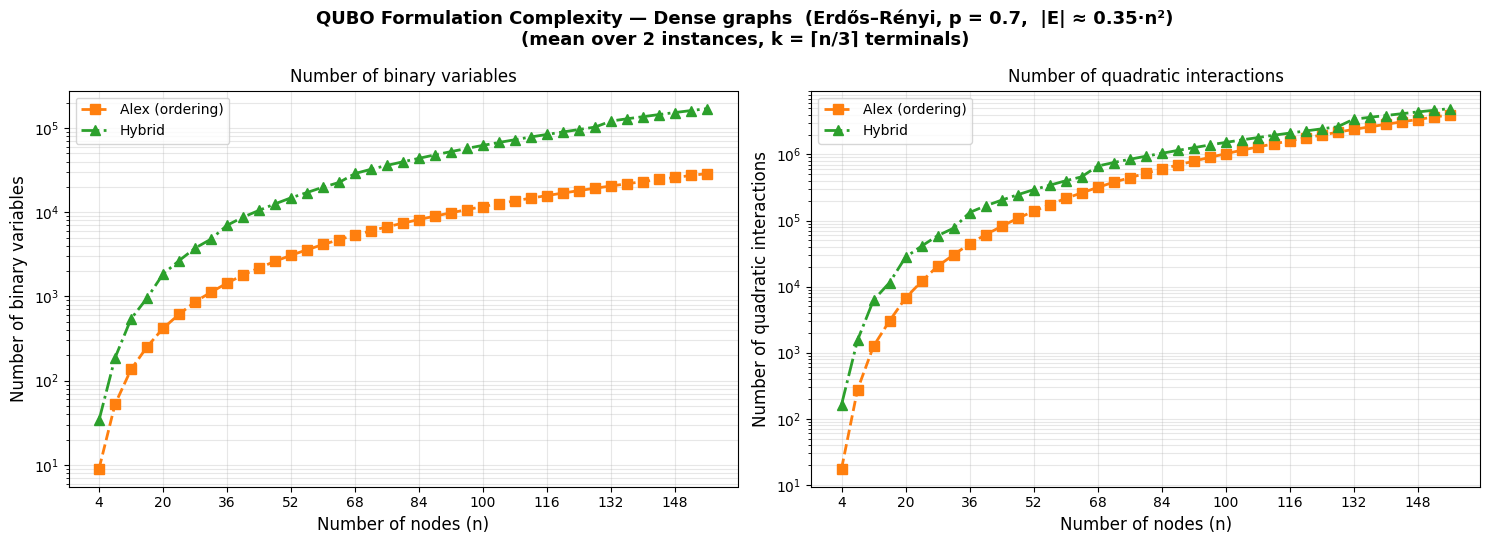

In [55]:
fig_dense = plot_complexity(
    dense_results2,
    NODE_SIZES,
    graph_label="Dense graphs  (Erdős–Rényi, p = 0.7,  |E| ≈ 0.35·n²)",
)

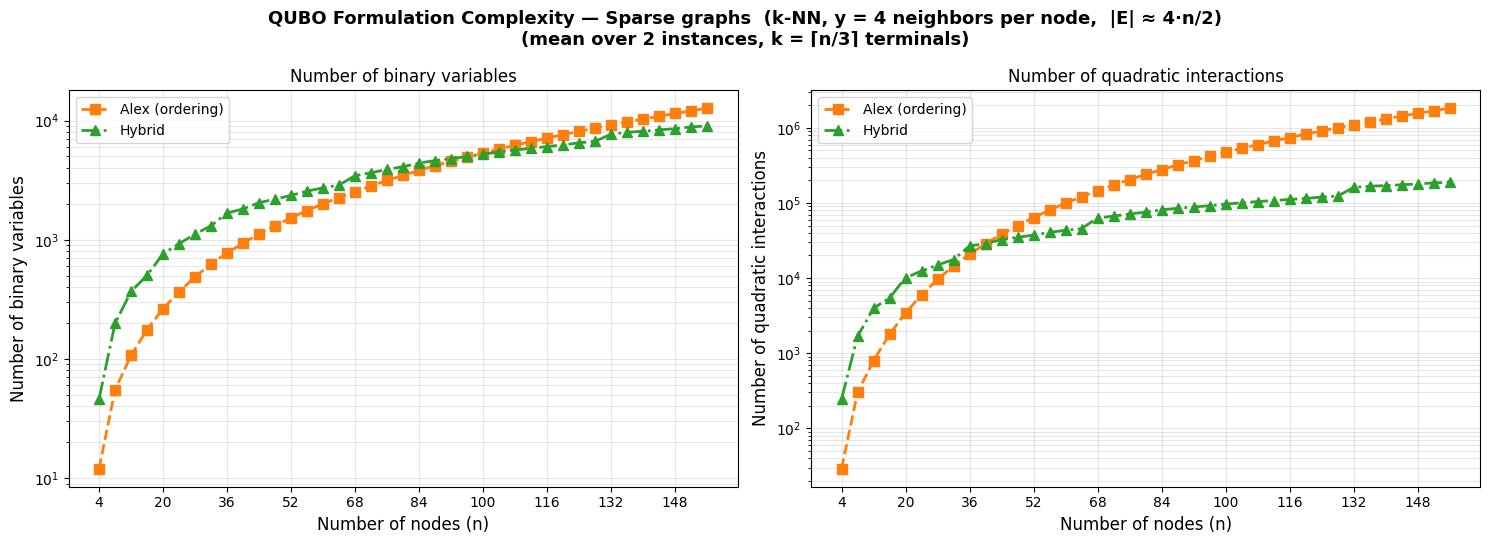

In [56]:
fig_sparse = plot_complexity(
    sparse_results2,
    NODE_SIZES,
    graph_label=f"Sparse graphs  (k-NN, y = {SPARSE_DEGREE} neighbors per node,  |E| ≈ {SPARSE_DEGREE}·n/2)",
)